In [1]:
# PHASE 6 — CLUSTERING K-MEANS (Segmentation RFM des Clients)
# Objectif : Segmenter les 93 350 clients en groupes homogènes
#            selon leur comportement RFM (Recency, Frequency, Monetary)
#            pour cibler les actions marketing.

In [4]:
# CELLULE 0 — Connexion Google Drive + Extraction dossier
from google.colab import drive
drive.mount('/content/drive')

import os

# Chemin du projet
PROJECT_PATH = "/content/drive/MyDrive/DDDM_Projet/projetDDD"

print("Contenu du dossier :")
print(os.listdir(PROJECT_PATH))

Mounted at /content/drive
Contenu du dossier :
['eda_ca_mensuel.png', 'eda_croissance_ca.png', 'eda_ca_categorie.png', 'eda_distribution_clients.png', 'eda_top_clients.png', 'eda_distribution_depenses.png', 'eda_clients_par_etat.png', 'eda_top_produits_volume.png', 'eda_produits_ca_vs_volume.png', 'eda_distribution_prix.png', 'eda_satisfaction.png', 'eda_satisfaction_categorie.png', 'eda_livraison_distribution.png', 'eda_retard_vs_satisfaction.png', 'eda_retard_mensuel.png', 'eda_correlation_heatmap.png', 'eda_scatter_matrix.png', 'eda_outliers_boxplot.png', 'eda_violin_plots.png', 'test1_retard_satisfaction.png', 'test2_categorie_satisfaction.png', 'test3_fidelite_depense.png', 'test5_etat_retard.png', 'test_recap_pvalues.png', 'code.zip', 'Amazon Product Reviews Dataset', 'Instacart Market Basket Analysis', 'code', 'Brazilian E-Commerce Public Dataset by Olist']


In [5]:
# CELLULE 1 — Imports et Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Style global des graphiques
plt.rcParams['figure.figsize']  = (12, 6)
plt.rcParams['font.size']       = 11
plt.rcParams['axes.titlesize']  = 14
plt.rcParams['axes.labelsize']  = 12
PALETTE = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']

print("Imports OK")

Imports OK


In [6]:
# CELLULE 2 — Chargement du Dataset Analytique (Phase 3)

CA_PATH = "/content/drive/MyDrive/DDDM_Projet/projetDDD/code/customer_analytics.csv"

ca = pd.read_csv(CA_PATH)

print(f"Dataset chargé : {ca.shape[0]:,} lignes")
print(f"Nombre de colonnes : {ca.shape[1]}")
print("\nColonnes disponibles :")
print(ca.columns.tolist())

ca.head()

Dataset chargé : 93,350 lignes
Nombre de colonnes : 19

Colonnes disponibles :
['customer_unique_id', 'recency_days', 'nb_orders', 'total_spent', 'avg_order_value', 'max_order_value', 'avg_basket_size', 'total_items', 'avg_delivery_days', 'avg_delay', 'late_rate', 'avg_review_score', 'active_days', 'purchase_frequency', 'customer_state', 'first_order_date', 'last_order_date', 'is_loyal', 'is_high_value']


,customer_unique_id,recency_days,nb_orders,total_spent,avg_order_value,max_order_value,avg_basket_size,total_items,avg_delivery_days,avg_delay,late_rate,avg_review_score,active_days,purchase_frequency,customer_state,first_order_date,last_order_date,is_loyal,is_high_value
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,141.90,141.90,1.0,1,6.0,-5.0,0.0,5.0,0,30.0,SP,2018-05-10 10:56:27,2018-05-10 10:56:27,0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,27.19,27.19,1.0,1,3.0,-5.0,0.0,4.0,0,30.0,SP,2018-05-07 11:11:27,2018-05-07 11:11:27,0,0
2,0000f46a3911fa3c0805444483337064,537,1,86.22,86.22,86.22,1.0,1,25.0,-2.0,0.0,3.0,0,30.0,SC,2017-03-10 21:05:03,2017-03-10 21:05:03,0,0
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,43.62,43.62,1.0,1,20.0,-12.0,0.0,4.0,0,30.0,PA,2017-10-12 20:29:41,2017-10-12 20:29:41,0,0
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,196.89,196.89,1.0,1,13.0,-8.0,0.0,5.0,0,30.0,SP,2017-11-14 19:45:42,2017-11-14 19:45:42,0,1


In [7]:
# CELLULE 3 — Construction de la Matrice RFM

# RFM = Recency (récence), Frequency (fréquence), Monetary (montant)
# Ces 3 variables sont déjà dans customer_analytics.csv grâce à la Phase 3

# Recency   : nombre de jours depuis le dernier achat.
# Frequency : nombre total de commandes.
# Monetary  : montant total dépensé.
# Cette méthode est très utilisée en marketing analytique
# pour segmenter les clients selon leur valeur commerciale.

rfm = ca[['customer_unique_id', 'recency_days', 'nb_orders', 'total_spent']].copy()
rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

print("=== Statistiques RFM ===")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

=== Statistiques RFM ===
        Recency  Frequency  Monetary
count  93350.00   93350.00  93350.00
mean     237.95       1.03    165.20
std      152.59       0.21    226.32
min        1.00       1.00      0.00
25%      114.00       1.00     63.05
50%      219.00       1.00    107.78
75%      346.00       1.00    182.55
max      714.00      15.00  13664.08


In [8]:
# CELLULE 4 — Normalisation des Variables RFM

# K-Means est sensible aux échelles → on normalise avec StandardScaler

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print("✓ Normalisation appliquée")
print(f"  Moyenne après scaling : {X_scaled.mean(axis=0).round(4)}")
print(f"  Écart-type après scaling : {X_scaled.std(axis=0).round(4)}")

✓ Normalisation appliquée
  Moyenne après scaling : [-0.  0. -0.]
  Écart-type après scaling : [1. 1. 1.]


Calcul en cours (peut prendre 2-3 minutes sur Colab)...
  K=2 | Inertia=201642 | Silhouette=0.7385
  K=3 | Inertia=137732 | Silhouette=0.4533
  K=4 | Inertia=92092 | Silhouette=0.4888
  K=5 | Inertia=77429 | Silhouette=0.4141
  K=6 | Inertia=63547 | Silhouette=0.4334
  K=7 | Inertia=54079 | Silhouette=0.4343
  K=8 | Inertia=48390 | Silhouette=0.4458
  K=9 | Inertia=43722 | Silhouette=0.3784
  K=10 | Inertia=39668 | Silhouette=0.3784


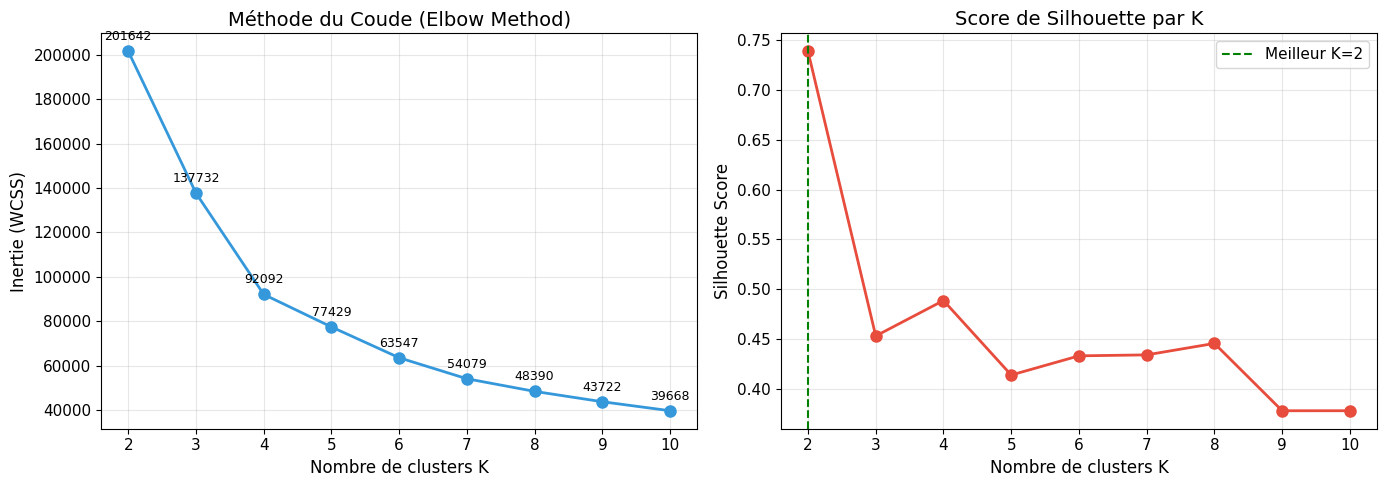


✓ Meilleur K selon Silhouette : 2


In [14]:
# CELLULE 5 — Méthode du Coude (Elbow Method) pour choisir K
# Choix du nombre optimal de clusters.
#
# Deux critères sont utilisés :
# 1. Elbow Method : cherche le point où la diminution de l'inertie ralentit.
# 2. Silhouette Score : mesure la qualité de séparation des clusters.
# Le meilleur K est celui qui équilibre ces deux critères.
# On teste K de 2 à 10 et on observe l'inertie (WCSS)

inertias       = []
silhouette_scores = []
K_range        = range(2, 11)

print("Calcul en cours (peut prendre 2-3 minutes sur Colab)...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, kmeans.labels_, sample_size=5000, random_state=42)
    silhouette_scores.append(sil)
    print(f"  K={k} | Inertia={kmeans.inertia_:.0f} | Silhouette={sil:.4f}")

# Graphique : Méthode du Coude + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe d'inertie
axes[0].plot(list(K_range), inertias, 'o-', color='#3498db', linewidth=2, markersize=8)
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie (WCSS)')
axes[0].set_title('Méthode du Coude (Elbow Method)')
axes[0].grid(True, alpha=0.3)
for k, i in zip(K_range, inertias):
    axes[0].annotate(f'{i:.0f}', (k, i), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)

# Courbe Silhouette
axes[1].plot(list(K_range), silhouette_scores, 'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Score de Silhouette par K')
axes[1].grid(True, alpha=0.3)
best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(x=best_k, color='green', linestyle='--', label=f'Meilleur K={best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('phase6_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Meilleur K selon Silhouette : {best_k}")

In [15]:
# CELLULE 6 — Application de K-Means avec K=4

# On choisit K=4 (bon équilibre entre complexité et interprétabilité métier)

K_OPTIMAL = 4

kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Ajouter le cluster au dataset principal
ca['Cluster'] = rfm['Cluster'].values

print(f"✓ K-Means appliqué avec K={K_OPTIMAL}")
print("\nRépartition des clusters :")
print(rfm['Cluster'].value_counts().sort_index())

✓ K-Means appliqué avec K=4

Répartition des clusters :
Cluster
0    50636
1    37524
2     2418
3     2772
Name: count, dtype: int64


In [16]:
# CELLULE 7 — Analyse des Clusters (Profils RFM)

cluster_profiles = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].agg(['mean','median','count'])
cluster_profiles.columns = ['_'.join(c) for c in cluster_profiles.columns]
cluster_profiles = cluster_profiles.round(2)

print("\n=== PROFILS DES CLUSTERS ===")
print(cluster_profiles.to_string())

# Moyennes normalisées pour radar chart
cluster_means = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()


=== PROFILS DES CLUSTERS ===
         Recency_mean  Recency_median  Recency_count  Frequency_mean  Frequency_median  Frequency_count  Monetary_mean  Monetary_median  Monetary_count
Cluster                                                                                                                                                
0              128.08           129.0          50636            1.00               1.0            50636         134.36           103.64           50636
1              387.41           374.0          37524            1.00               1.0            37524         133.46           101.34           37524
2              239.40           225.0           2418            1.01               1.0             2418        1160.91           935.94            2418
3              220.44           199.0           2772            2.11               2.0             2772         289.68           223.90            2772


In [17]:
# CELLULE 8 — Nommage des Segments (Interprétation Métier)

# Interprétation métier des clusters.
# Les clusters calculés par K-Means sont purement numériques. Afin de faciliter leur exploitation métier, ils sont
# renommés selon leur profil RFM.

# On nomme chaque cluster selon son profil RFM.
# LOGIQUE :
#   - Recency faible  = achat récent (bon signe)
#   - Frequency haute = achète souvent (fidèle)
#   - Monetary haute  = dépense beaucoup (valeur élevée)

# Calculer un score composite pour aider au nommage
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())
cluster_means_norm['Recency_inv'] = 1 - cluster_means_norm['Recency']  # inverser : récence faible = bon

# Afficher pour décider du nommage
print("\n=== MOYENNES NORMALISÉES (0=pire, 1=meilleur) ===")
print(cluster_means_norm.round(3))

# Nommage automatique basé sur les rangs
# (Tu peux ajuster manuellement selon tes résultats)
scores = cluster_means_norm['Recency_inv'] + cluster_means_norm['Frequency'] + cluster_means_norm['Monetary']
ranking = scores.rank(ascending=False).astype(int)

segment_names = {}
for cluster_id, rank in ranking.items():
    if rank == 1:
        segment_names[cluster_id] = 'Champions'
    elif rank == 2:
        segment_names[cluster_id] = 'Clients Fidèles'
    elif rank == 3:
        segment_names[cluster_id] = 'Clients Occasionnels'
    else:
        segment_names[cluster_id] = 'Clients à Risque'

rfm['Segment']  = rfm['Cluster'].map(segment_names)
ca['Segment']   = ca['Cluster'].map(segment_names)

print("\n=== NOMMAGE DES SEGMENTS ===")
for k, v in segment_names.items():
    n = (rfm['Cluster'] == k).sum()
    print(f"  Cluster {k} → {v} ({n:,} clients, {n/len(rfm)*100:.1f}%)")


=== MOYENNES NORMALISÉES (0=pire, 1=meilleur) ===
         Recency  Frequency  Monetary  Recency_inv
Cluster                                           
0          0.000      0.000     0.001        1.000
1          1.000      0.000     0.000        0.000
2          0.429      0.012     1.000        0.571
3          0.356      1.000     0.152        0.644

=== NOMMAGE DES SEGMENTS ===
  Cluster 0 → Clients Occasionnels (50,636 clients, 54.2%)
  Cluster 1 → Clients à Risque (37,524 clients, 40.2%)
  Cluster 2 → Clients Fidèles (2,418 clients, 2.6%)
  Cluster 3 → Champions (2,772 clients, 3.0%)


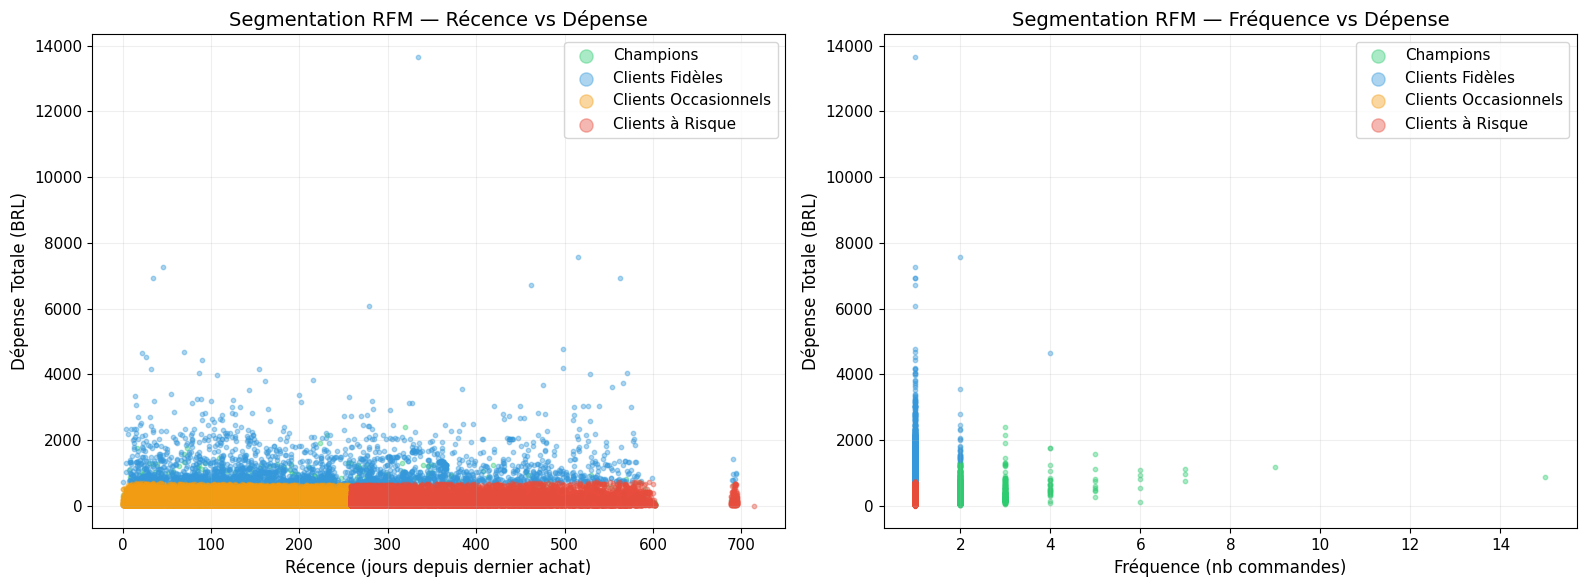

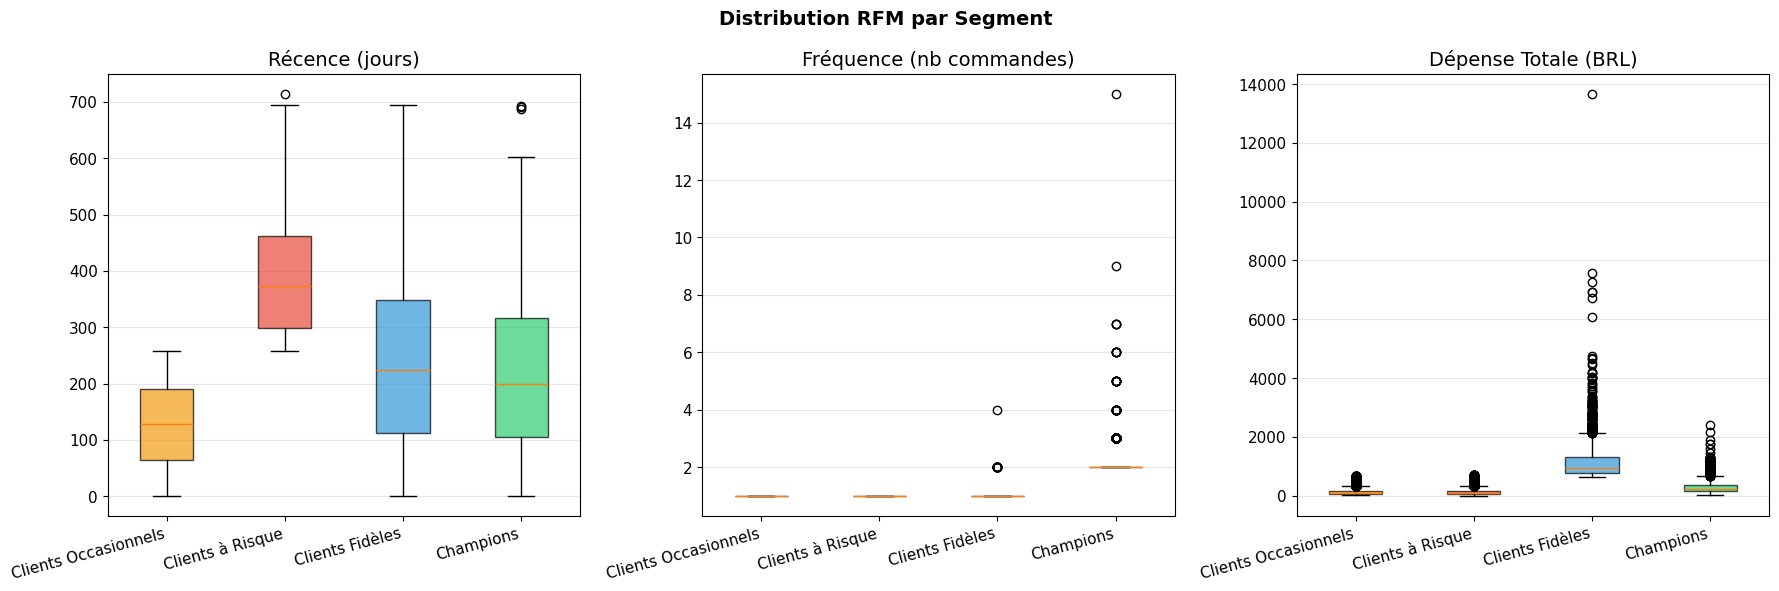

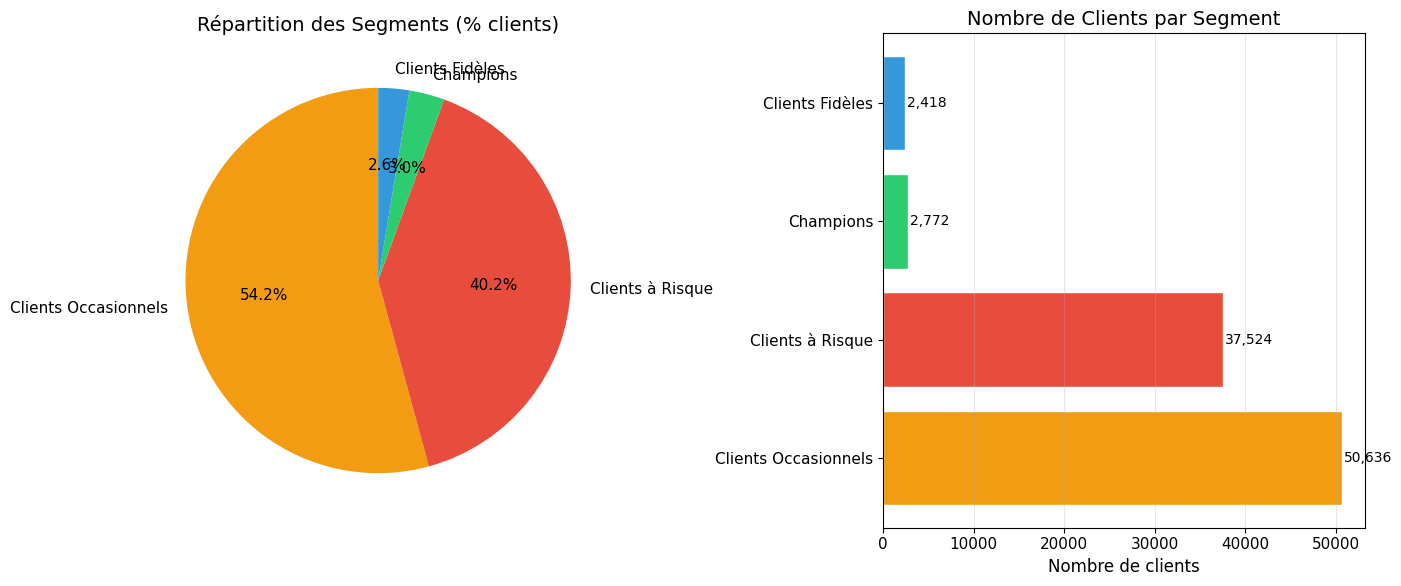

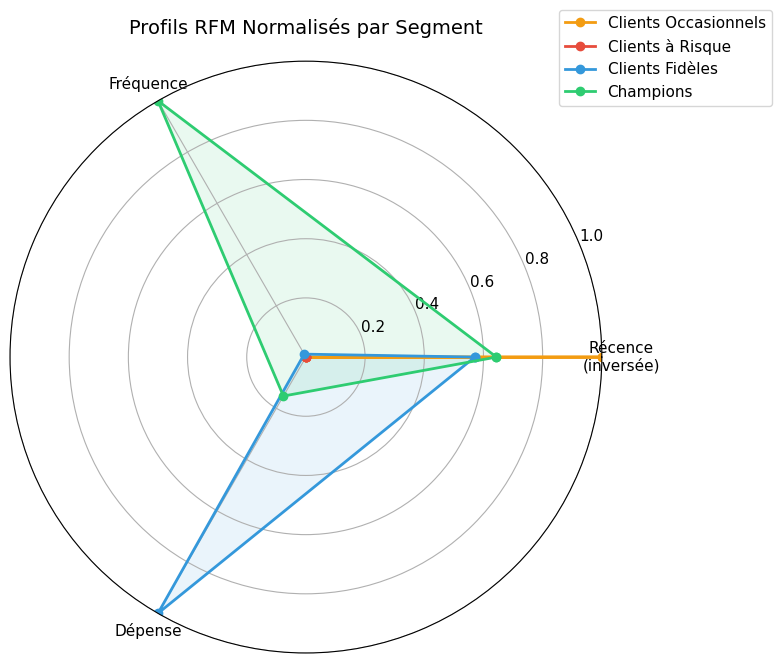

In [18]:
# CELLULE 9 — Visualisations des Clusters

segment_colors = {
    'Champions'          : '#2ecc71',
    'Clients Fidèles'    : '#3498db',
    'Clients Occasionnels': '#f39c12',
    'Clients à Risque'   : '#e74c3c'
}
rfm['color'] = rfm['Segment'].map(segment_colors)

# --- 9.1 Scatter plot Recency vs Monetary ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for seg, grp in rfm.groupby('Segment'):
    axes[0].scatter(grp['Recency'], grp['Monetary'],
                    c=segment_colors[seg], label=seg, alpha=0.4, s=10)
axes[0].set_xlabel('Récence (jours depuis dernier achat)')
axes[0].set_ylabel('Dépense Totale (BRL)')
axes[0].set_title('Segmentation RFM — Récence vs Dépense')
axes[0].legend(markerscale=3)
axes[0].grid(True, alpha=0.2)

# --- 9.2 Scatter plot Frequency vs Monetary ---
for seg, grp in rfm.groupby('Segment'):
    axes[1].scatter(grp['Frequency'], grp['Monetary'],
                    c=segment_colors[seg], label=seg, alpha=0.4, s=10)
axes[1].set_xlabel('Fréquence (nb commandes)')
axes[1].set_ylabel('Dépense Totale (BRL)')
axes[1].set_title('Segmentation RFM — Fréquence vs Dépense')
axes[1].legend(markerscale=3)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('phase6_scatter_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 9.3 Boxplots RFM par segment ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
vars_rfm = ['Recency', 'Frequency', 'Monetary']
titles   = ['Récence (jours)', 'Fréquence (nb commandes)', 'Dépense Totale (BRL)']

for ax, var, title in zip(axes, vars_rfm, titles):
    order = list(segment_names.values())
    colors = [segment_colors[s] for s in order]
    data_list = [rfm[rfm['Segment'] == s][var].values for s in order]
    bp = ax.boxplot(data_list, labels=order, patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title)
    ax.set_xticklabels(order, rotation=15, ha='right')
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Distribution RFM par Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('phase6_boxplots_rfm.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 9.4 Répartition des segments (Pie chart + Bar chart) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

counts = rfm['Segment'].value_counts()
colors_list = [segment_colors[s] for s in counts.index]

axes[0].pie(counts.values, labels=counts.index, colors=colors_list,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Répartition des Segments (% clients)')

axes[1].barh(counts.index, counts.values, color=colors_list, edgecolor='white')
axes[1].set_xlabel('Nombre de clients')
axes[1].set_title('Nombre de Clients par Segment')
for i, v in enumerate(counts.values):
    axes[1].text(v + 200, i, f'{v:,}', va='center', fontsize=10)
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('phase6_segments_repartition.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 9.5 Radar Chart (Spider Chart) par segment ---
from matplotlib.patches import FancyArrowPatch

categories  = ['Récence\n(inversée)', 'Fréquence', 'Dépense']
N           = len(categories)
angles      = [n / float(N) * 2 * np.pi for n in range(N)]
angles     += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for seg in segment_names.values():
    cluster_id = [k for k, v in segment_names.items() if v == seg][0]
    row        = cluster_means_norm.loc[cluster_id]
    values     = [1 - row['Recency'], row['Frequency'], row['Monetary']]
    values    += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=segment_colors[seg], label=seg)
    ax.fill(angles, values, alpha=0.1, color=segment_colors[seg])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_title('Profils RFM Normalisés par Segment', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.savefig('phase6_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# CELLULE 10 — Tableau de Synthèse des Segments

summary = rfm.groupby('Segment').agg(
    Nb_Clients     = ('customer_unique_id', 'count'),
    Recence_Moy    = ('Recency',   'mean'),
    Frequence_Moy  = ('Frequency', 'mean'),
    Depense_Moy    = ('Monetary',  'mean'),
    Depense_Med    = ('Monetary',  'median'),
    Depense_Total  = ('Monetary',  'sum')
).round(2)
summary['Part_CA_%']     = (summary['Depense_Total'] / summary['Depense_Total'].sum() * 100).round(1)
summary['Part_Clients_%'] = (summary['Nb_Clients']   / summary['Nb_Clients'].sum()   * 100).round(1)

print("\n" + "=" * 70)
print(" TABLEAU DE SYNTHÈSE DES SEGMENTS")
print("=" * 70)
print(summary.to_string())


 TABLEAU DE SYNTHÈSE DES SEGMENTS
                      Nb_Clients  Recence_Moy  Frequence_Moy  Depense_Moy  Depense_Med  Depense_Total  Part_CA_%  Part_Clients_%
Segment                                                                                                                         
Champions                   2772       220.44           2.11       289.68       223.90      802993.66        5.2             3.0
Clients Fidèles             2418       239.40           1.01      1160.91       935.94     2807071.54       18.2             2.6
Clients Occasionnels       50636       128.08           1.00       134.36       103.64     6803210.57       44.1            54.2
Clients à Risque           37524       387.41           1.00       133.46       101.34     5007807.08       32.5            40.2


In [20]:
# CELLULE 11 — Export du Dataset Enrichi avec Segments

# Sauvegarde du dataset enrichi.
# Les nouvelles colonnes Cluster et Segment seront utilisées dans les phases suivantes :
# Le fichier exporté constitue donc la nouvelle base analytique enrichie du projet.

ca.to_csv('customer_analytics_segmented.csv', index=False)
print("\n✓ Dataset enrichi exporté : customer_analytics_segmented.csv")
print(f"  Colonnes ajoutées : Cluster, Segment")
print(f"  Dimensions : {ca.shape}")

# Copie sur Google Drive
import shutil
shutil.copy(
    'customer_analytics_segmented.csv',
    '/content/drive/MyDrive/DDDM_Projet/projetDDD/code/customer_analytics_segmented.csv'
)
print("✓ Copié sur Google Drive")


✓ Dataset enrichi exporté : customer_analytics_segmented.csv
  Colonnes ajoutées : Cluster, Segment
  Dimensions : (93350, 21)
✓ Copié sur Google Drive


In [21]:
# CELLULE 12 — Synthèse Phase 6
print("=" * 70)
print(" SYNTHÈSE PHASE 6 : CLUSTERING K-MEANS")
print("=" * 70)
print(f"""
PARAMÈTRES
  K optimal retenu    : {K_OPTIMAL}
  Méthode évaluation  : Elbow + Silhouette Score

SEGMENTS IDENTIFIÉS""")
for seg in segment_names.values():
    row = summary.loc[seg]
    print(f"  {seg:25} | {int(row['Nb_Clients']):>6,} clients ({row['Part_Clients_%']:.1f}%) "
          f"| Dép. moy. {row['Depense_Moy']:.0f} BRL "
          f"| Rép. CA {row['Part_CA_%']:.1f}%")

graphs = ['phase6_elbow_silhouette.png', 'phase6_scatter_clusters.png',
          'phase6_boxplots_rfm.png', 'phase6_segments_repartition.png',
          'phase6_radar_chart.png']
print(f"\nGraphiques sauvegardés ({len(graphs)}) :")
for g in graphs:
    print(f"  ✓ {g}")

print("\n✓ Phase 6 terminée — prêt pour Phase 7 (Feature Engineering ML)")

 SYNTHÈSE PHASE 6 : CLUSTERING K-MEANS

PARAMÈTRES
  K optimal retenu    : 4
  Méthode évaluation  : Elbow + Silhouette Score
 
SEGMENTS IDENTIFIÉS
  Clients Occasionnels      | 50,636 clients (54.2%) | Dép. moy. 134 BRL | Rép. CA 44.1%
  Clients à Risque          | 37,524 clients (40.2%) | Dép. moy. 133 BRL | Rép. CA 32.5%
  Clients Fidèles           |  2,418 clients (2.6%) | Dép. moy. 1161 BRL | Rép. CA 18.2%
  Champions                 |  2,772 clients (3.0%) | Dép. moy. 290 BRL | Rép. CA 5.2%

Graphiques sauvegardés (5) :
  ✓ phase6_elbow_silhouette.png
  ✓ phase6_scatter_clusters.png
  ✓ phase6_boxplots_rfm.png
  ✓ phase6_segments_repartition.png
  ✓ phase6_radar_chart.png

✓ Phase 6 terminée — prêt pour Phase 7 (Feature Engineering ML)
